# Core-collapse supernovae

This page is the reference for the built-in core-collapse supernova (CC SN) models:
{class}`skysurvey.SNeII`, {class}`skysurvey.SNeIIn`, {class}`skysurvey.SNeIIb`, {class}`skysurvey.SNeIb`,
{class}`skysurvey.SNeIc` and {class}`skysurvey.SNeIcBL`. You will see which templates they use, their default
rates, and how their parameters are drawn.

:::{tip}
If you are new to `skysurvey`, start with the [target quickstart](../quickstart/quickstart_target.ipynb).
This page focuses on the *default settings* of the CC SN models.
:::

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import skysurvey
from skysurvey.target.sncc import CC_RATE
from skysurvey.target.rates import get_ntargets

## Overview

All six classes share the same structure and only differ by their templates, rate and absolute-magnitude
distribution. Each class combines:

- {class}`~skysurvey.target.sncc.VincenziModels`, which loads all the Vincenzi et al. (2019) templates
  of the given sub-type available in `sncosmo`;
- {class}`~skysurvey.target.timeserie.MultiTemplateTSTransient`, which draws, for each simulated
  supernova, one template among them.

Let us gather the default properties of each class:

In [2]:
classes = [skysurvey.SNeII, skysurvey.SNeIIn, skysurvey.SNeIIb,
           skysurvey.SNeIb, skysurvey.SNeIc, skysurvey.SNeIcBL]
targets = {cls.__name__: cls() for cls in classes}  # loading templates takes a few seconds

for name, target in targets.items():
    mean, sigma = target._MAGABS
    print(f"{name:8s} kind={target.kind!r:11s} rate={target.rate:>8,.0f} /Gpc3/yr  "
          f"magabs=N({mean}, {sigma})  ntemplates={target.template.ntemplates}")

SNeII    kind='SN II'     rate=  64,900 /Gpc3/yr  magabs=N(-17.48, 0.7)  ntemplates=23


SNeIIn   kind='SN IIn'    rate=   4,700 /Gpc3/yr  magabs=N(-18.0, 0.8)  ntemplates=6


SNeIIb   kind='SN IIb'    rate=  10,900 /Gpc3/yr  magabs=N(-17.45, 0.6)  ntemplates=12


SNeIb    kind='SN Ib'     rate=  10,800 /Gpc3/yr  magabs=N(-17.35, 0.53)  ntemplates=12


SNeIc    kind='SN Ic'     rate=   7,500 /Gpc3/yr  magabs=N(-17.5, 0.7)  ntemplates=7


SNeIcBL  kind='SN Ic-BL'  rate=   9,700 /Gpc3/yr  magabs=N(-18.12, 0.9)  ntemplates=6


## Templates

The spectral templates are the Vincenzi et al. (2019) spectrophotometric time series, built from well-observed
CC SNe and distributed with [sncosmo](https://sncosmo.readthedocs.io/en/stable/source-list.html) under the
names `v19-<sn name>-corr` (the `-corr` versions are corrected for host-galaxy extinction).
The class collects them in a {class}`~skysurvey.template.TemplateCollection`:

In [3]:
snii = targets["SNeII"]
snii.template.names[:8]  # first 8 out of 23

['v19-asassn14jb-corr',
 'v19-asassn15oz-corr',
 'v19-1987a-corr',
 'v19-1999em-corr',
 'v19-2004et-corr',
 'v19-2007od-corr',
 'v19-2008bj-corr',
 'v19-2008in-corr']

Each template is a regular `sncosmo` time-series source with three parameters: `z`, `t0` (the time of the
template's phase zero, close to peak brightness for these templates) and `amplitude` (set by `skysurvey` from the drawn absolute magnitude):

In [4]:
snii.template.parameters

['z', 't0', 'amplitude']

The templates capture the diversity of light-curve shapes within and between the sub-types. Below, every template
of every class is shown in the rest-frame Bessell R band, normalized to its peak:

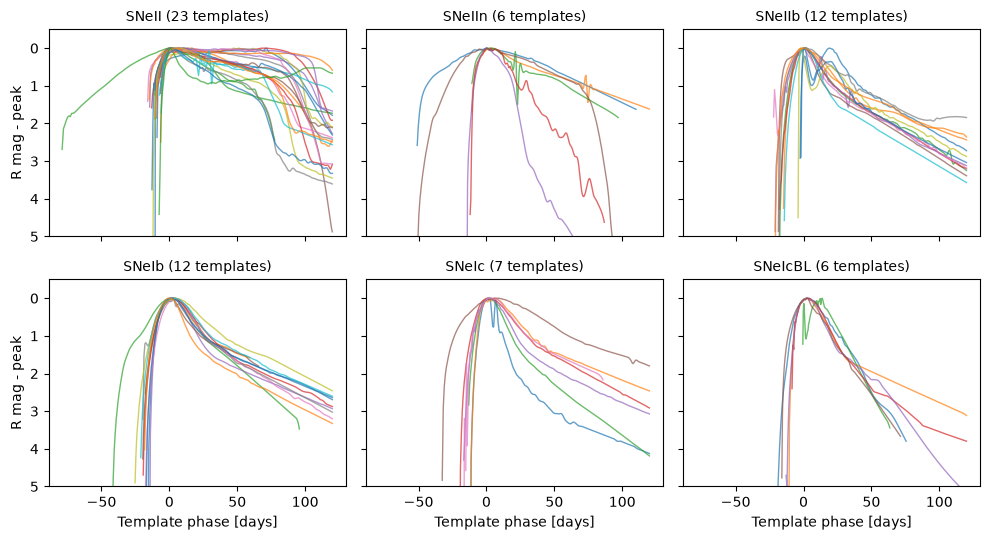

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5), sharex=True, sharey=True)
for ax, (name, target) in zip(axes.flat, targets.items()):
    for i in range(target.template.ntemplates):
        model = target.template.get(ref_index=i)
        phase = np.linspace(model.mintime(), min(model.maxtime(), 120), 200)
        with np.errstate(divide="ignore", invalid="ignore"):  # harmless: no flux at the template edges
            mag = model.bandmag("bessellr", "ab", phase)
        ax.plot(phase, mag - np.nanmin(mag), lw=1, alpha=0.7)
    ax.set_title(f"{name} ({target.template.ntemplates} templates)", fontsize="medium")
axes[0, 0].set_ylim(5, -0.5)
for ax in axes[1]:
    ax.set_xlabel("Template phase [days]")
for ax in axes[:, 0]:
    ax.set_ylabel("R mag - peak")
fig.tight_layout()

## Rate

The rates are fractions of the total CC SN volumetric rate, $10^{5}\ \mathrm{Gpc^{-3}\,yr^{-1}}$
(`CC_RATE`, from Perley et al. 2020, assuming $H_0=70$), split by sub-type using the relative fractions
of Vincenzi et al. (2019):

| Class | Fraction of `CC_RATE` | Rate [$\mathrm{Gpc^{-3}\,yr^{-1}}$] |
|---|---|---|
| `SNeII` (IIP + IIL) | 0.649 | 64 900 |
| `SNeIIn` | 0.047 | 4 700 |
| `SNeIIb` | 0.109 | 10 900 |
| `SNeIb` | 0.108 | 10 800 |
| `SNeIc` | 0.075 | 7 500 |
| `SNeIcBL` (Ic-BL + Ic-pec) | 0.097 | 9 700 |

:::{note}
These fractions add up to 1.085, so the sum of the six default rates is slightly larger than `CC_RATE`.
:::

As for any transient, the rate is constant with redshift, rescaled by $(H_0/70)^3$ to the target cosmology
and divided by $(1+z)$ for time dilation. Since CC SNe are fainter than SNe Ia, their default `zmax` is 0.05.
Here is the number of events expected per year, over the full sky, at $z<0.05$:

CC_RATE = 100000.0


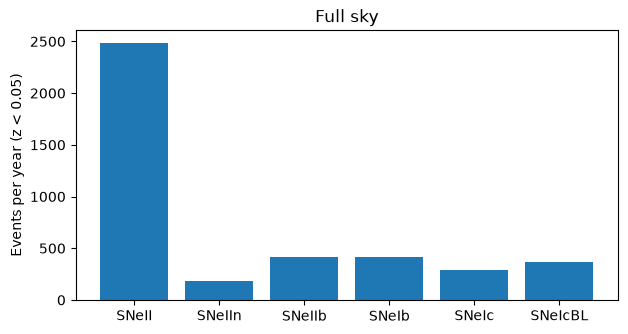

In [6]:
names = list(targets)
nyear = [get_ntargets(0.05, rate=t.rate, rate_H0=t._rateh0, cosmology=t.cosmology) for t in targets.values()]
print("CC_RATE =", CC_RATE)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(names, nyear, color="tab:blue")
ax.set(ylabel="Events per year (z < 0.05)", title="Full sky");

To use another rate, see [change the rate](../howto/change_rate.ipynb).

## Model

The model is the generic time-series transient model ({class}`~skysurvey.target.timeserie.TSTransient`)
plus a `template` entry that picks one template per target:

In [7]:
snii.model

{'redshift': {'kwargs': {'zmax': 0.05}, 'as': 'z'},
 't0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x10498F3E0>,
        'kwargs': {'low': 56000, 'high': 56200}},
 'magabs': {'func': <bound method Generator.normal of Generator(PCG64) at 0x1684BDA80>,
            'kwargs': {'loc': -17.48, 'scale': 0.7}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'radec': {'func': <function random_radec at 0x157d81ee0>,
           'as': ['ra', 'dec'],
           'kwargs': {}},
 'template': {'func': 'draw_template', 'kwargs': {'redshift': '@z'}}}

| Entry | Default |
|---|---|
| `redshift` | follows the rate, $z \le 0.05$ |
| `t0` | uniform between MJD 56 000 and 56 200 (set it with `tstart` and `tstop`) |
| `magabs` | Gaussian, $\mathcal{N}(\mu, \sigma)$ given by the class `_MAGABS` |
| `magobs` | `magabs` + distance modulus $\mu(z)$ |
| `radec` | uniform over the full sky |
| `template` | uniform among the class templates (they all share the same rate) |

### Absolute magnitude

The peak absolute magnitudes are Gaussian, with mean and scatter taken from the ZTF Bright Transient Survey
(BTS) sample at $z<0.05$ (Perley et al. 2020). The values from Table 1 of Vincenzi et al. (2019) are kept as comments
in the source code (`skysurvey/target/sncc.py`).

:::{note}
As for every `skysurvey` target, `magabs` sets the peak magnitude in the band given by `peak_absmag_band`
(rest-frame Bessell B, AB system), while the BTS values are R-band peak magnitudes.
:::

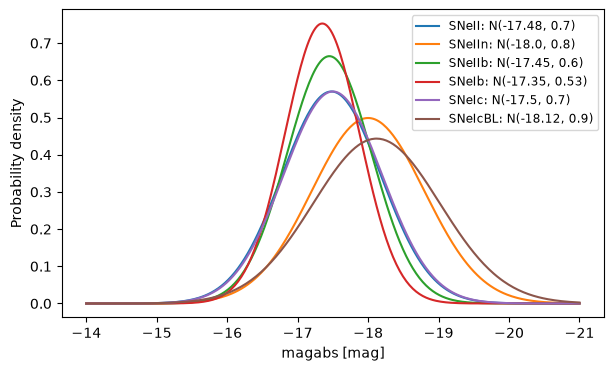

In [8]:
mag = np.linspace(-21, -14, 300)
fig, ax = plt.subplots(figsize=(7, 4))
for name, target in targets.items():
    mean, sigma = target._MAGABS
    ax.plot(mag, stats.norm.pdf(mag, mean, sigma), label=f"{name}: N({mean}, {sigma})")
ax.invert_xaxis()
ax.set(xlabel="magabs [mag]", ylabel="Probability density")
ax.legend(fontsize="small");

## Usage example

The most common way to use these classes is `from_draw()`. Here we simulate 2 000 SNe Ib:

In [9]:
snib = skysurvey.SNeIb.from_draw(size=2_000)
snib.data.head()

,z,t0,magabs,ra,dec,magobs,template
0,0.03475,56160.152344,-17.794170,0.092592,42.834759,18.199423,v19-2007uy-corr
1,0.04495,56145.039062,-17.108990,81.657661,46.710461,19.459486,v19-2006ep-corr
2,0.02375,56164.257812,-18.074146,239.700668,-30.387115,17.075459,v19-2004gq-corr
3,0.00635,56011.843750,-16.791761,104.573853,-3.930326,15.465073,v19-2009jf-corr
4,0.04925,56035.378906,-16.742451,120.048737,55.120483,20.031082,v19-iptf13bvn-corr


Each target has its own `template`. Since all templates share the same rate, they are drawn uniformly:

In [10]:
snib.data["template"].value_counts().head()

template
v19-2012au-corr       186
v19-2005hg-corr       184
v19-iptf13bvn-corr    176
v19-2007uy-corr       169
v19-2008d-corr        168
Name: count, dtype: int64

The absolute-magnitude distribution can be changed with the `magabs` option: two values `(loc, scale)` for a
Gaussian, or three values `(loc, scale_low, scale_high)` for an asymmetric Gaussian. For instance, to use
the SN II luminosity function of Vincenzi et al. (2019), Table 1:

In [11]:
snii_v19 = skysurvey.SNeII.from_draw(size=2_000, magabs=(-16.0, 1.3))
snii_v19.model.model["magabs"]["kwargs"]

{'loc': -16.0, 'scale': 1.3}

And here is the true light curve of one simulated SN Ib. {meth}`~skysurvey.SNeIb.get_template` returns the
`sncosmo.Model` of that target, with all its parameters set (`set_magabs=True` sets its amplitude from `magabs`):

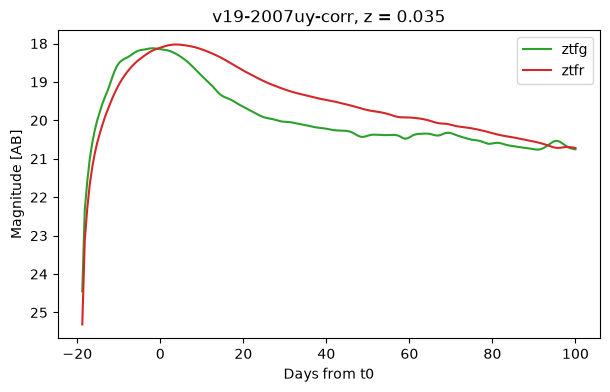

In [12]:
t0, z, template = snib.data.loc[0, ["t0", "z", "template"]]
times = np.linspace(t0 - 20, t0 + 100, 200)
model = snib.get_template(index=0, as_model=True, set_magabs=True)

fig, ax = plt.subplots(figsize=(7, 4))
for band, color in [("ztfg", "tab:green"), ("ztfr", "tab:red")]:
    with np.errstate(divide="ignore"):  # harmless: zero flux before the template starts
        ax.plot(times - t0, model.bandmag(band, "ab", times), color=color, label=band)
ax.invert_yaxis()
ax.set(xlabel="Days from t0", ylabel="Magnitude [AB]", title=f"{template}, z = {z:.3f}")
ax.legend();

## References

- Vincenzi et al. 2019, *Spectrophotometric templates for core-collapse supernovae and their application in simulations of time-domain surveys*,
  [MNRAS 489, 5802](https://ui.adsabs.harvard.edu/abs/2019MNRAS.489.5802V)
- Perley et al. 2020, *The Zwicky Transient Facility Bright Transient Survey. II.*,
  [ApJ 904, 35](https://ui.adsabs.harvard.edu/abs/2020ApJ...904...35P)
- The [sncosmo list of sources](https://sncosmo.readthedocs.io/en/stable/source-list.html) (`v19-*` templates).

## Next steps

- [Combine transients](../combining_transients.ipynb): simulate a mixed SN Ia + CC SN sample.
- [Change the rate](../howto/change_rate.ipynb) of a target.
- [Create a new transient class](../howto/create_new_transient_class.ipynb), e.g. from any other `sncosmo` template.
- [Simulate a dataset](../quickstart/quickstart_survey_target_dataset.ipynb): observe your targets with a survey.